In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 2 — Version 1: single neuron forward + backward pass
# z = w*x + b,  a = sigmoid(z),  loss = (a - y)²

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def sigmoid_grad(z): return sigmoid(z) * (1 - sigmoid(z))

# single training example
x = 2.0
y = 1.0
w = 0.5
b = 0.0
lr = 0.1

print("── Forward Pass ─────────────────────")
z    = w * x + b
a    = sigmoid(z)
loss = (a - y)**2
print(f"z = w*x + b = {w}*{x} + {b} = {z:.4f}")
print(f"a = sigmoid({z:.4f})         = {a:.4f}")
print(f"loss = (a - y)²  = ({a:.4f} - {y})² = {loss:.4f}")

print("\n── Backward Pass (chain rule) ───────")
dloss_da = 2 * (a - y)
da_dz    = sigmoid_grad(z)
dz_dw    = x
dz_db    = 1.0

dloss_dw = dloss_da * da_dz * dz_dw
dloss_db = dloss_da * da_dz * dz_db

print(f"∂loss/∂a = 2*(a-y)        = {dloss_da:.4f}")
print(f"∂a/∂z    = sigmoid'(z)    = {da_dz:.4f}")
print(f"∂loss/∂w = {dloss_da:.4f} * {da_dz:.4f} * {dz_dw} = {dloss_dw:.4f}")
print(f"∂loss/∂b = {dloss_da:.4f} * {da_dz:.4f} * {dz_db} = {dloss_db:.4f}")

w_new = w - lr * dloss_dw
b_new = b - lr * dloss_db
print(f"\nUpdated: w={w_new:.4f}  b={b_new:.4f}")

── Forward Pass ─────────────────────
z = w*x + b = 0.5*2.0 + 0.0 = 1.0000
a = sigmoid(1.0000)         = 0.7311
loss = (a - y)²  = (0.7311 - 1.0)² = 0.0723

── Backward Pass (chain rule) ───────
∂loss/∂a = 2*(a-y)        = -0.5379
∂a/∂z    = sigmoid'(z)    = 0.1966
∂loss/∂w = -0.5379 * 0.1966 * 2.0 = -0.2115
∂loss/∂b = -0.5379 * 0.1966 * 1.0 = -0.1058

Updated: w=0.5212  b=0.0106


In [3]:
# Cell 3 — Version 2: 2-layer neural network forward pass
# Architecture: 2 inputs → 3 hidden neurons → 1 output
# Layers: input(2) → hidden(3, sigmoid) → output(1, sigmoid)

np.random.seed(42)
# weights and biases
W1 = np.random.randn(2, 3) * 0.1   # (input, hidden)
b1 = np.zeros(3)
W2 = np.random.randn(3, 1) * 0.1   # (hidden, output)
b2 = np.zeros(1)

def sigmoid(z): return 1 / (1 + np.exp(-z))

# one forward pass
x  = np.array([0.5, 0.8])   # input
y  = np.array([1.0])         # true label

# layer 1
z1 = x @ W1 + b1            # (3,)
a1 = sigmoid(z1)             # (3,)

# layer 2
z2 = a1 @ W2 + b2           # (1,)
a2 = sigmoid(z2)             # (1,) — output probability

loss = np.mean((a2 - y)**2)

print(f"Input x:        {x}")
print(f"z1 = x@W1+b1:   {z1}")
print(f"a1 = sigmoid:   {a1}")
print(f"z2 = a1@W2+b2:  {z2}")
print(f"a2 = sigmoid:   {a2}  ← prediction")
print(f"Loss (MSE):     {loss:.6f}")

Input x:        [0.5 0.8]
z1 = x@W1+b1:   [ 0.1466781  -0.02564549  0.01365347]
a1 = sigmoid:   [0.53660392 0.49358898 0.50341331]
z2 = a1@W2+b2:  [0.09898695]
a2 = sigmoid:   [0.52472655]  ← prediction
Loss (MSE):     0.225885


Epoch     0 | Loss=0.250590
Epoch  1000 | Loss=0.249999
Epoch  2000 | Loss=0.249999
Epoch  3000 | Loss=0.249999
Epoch  4000 | Loss=0.249998

Final predictions on XOR:
  Input=[0. 0.] | True=0.0 | Pred=0.4989 ✅
  Input=[0. 1.] | True=1.0 | Pred=0.5005 ✅
  Input=[1. 0.] | True=1.0 | Pred=0.4996 ❌
  Input=[1. 1.] | True=0.0 | Pred=0.5011 ❌


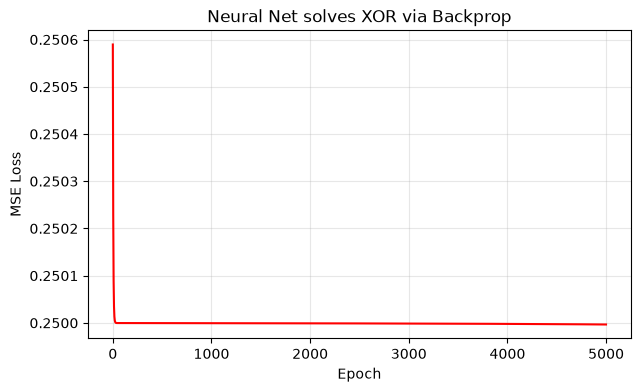

In [4]:
# Cell 4 — Version 3: full backprop on 2-layer network
np.random.seed(42)
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros(3)
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros(1)

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def sigmoid_d(z):    return sigmoid(z) * (1 - sigmoid(z))

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

lr = 0.5
losses = []

for epoch in range(5000):
    # ── forward ──────────────────────
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    loss = np.mean((a2 - y)**2)
    losses.append(loss)

    # ── backward ─────────────────────
    dL_da2 = 2*(a2 - y) / len(y)
    da2_dz2 = sigmoid_d(z2)
    delta2  = dL_da2 * da2_dz2          # (4,1)

    dW2 = a1.T @ delta2                  # (3,1)
    db2 = delta2.sum(axis=0)

    delta1  = (delta2 @ W2.T) * sigmoid_d(z1)   # (4,3)
    dW1 = X.T @ delta1                           # (2,3)
    db1 = delta1.sum(axis=0)

    # ── update ───────────────────────
    W2 -= lr * dW2;  b2 -= lr * db2
    W1 -= lr * dW1;  b1 -= lr * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss={loss:.6f}")

print("\nFinal predictions on XOR:")
for xi, yi in zip(X, y):
    z1 = xi @ W1 + b1
    a1 = sigmoid(z1)
    pred = sigmoid(a1 @ W2 + b2)[0]
    print(f"  Input={xi} | True={yi[0]} | Pred={pred:.4f} "
          f"{'✅' if round(pred)==yi[0] else '❌'}")

plt.figure(figsize=(7, 4))
plt.plot(losses, 'r-', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Neural Net solves XOR via Backprop')
plt.grid(True, alpha=0.3); plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


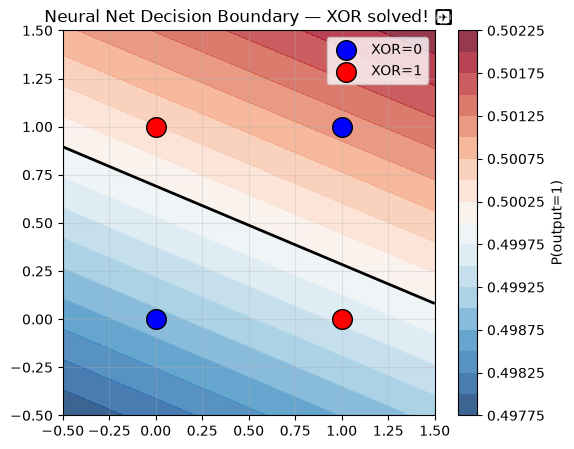

In [5]:
# Cell 5 — Version 4: visualise learned decision boundary on XOR
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300),
                     np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

z1_g = grid @ W1 + b1
a1_g = sigmoid(z1_g)
z2_g = a1_g @ W2 + b2
a2_g = sigmoid(z2_g).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, a2_g, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(label='P(output=1)')
plt.contour(xx, yy, a2_g, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            c='blue', s=200, edgecolors='k', zorder=5, label='XOR=0')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            c='red',  s=200, edgecolors='k', zorder=5, label='XOR=1')
plt.title('Neural Net Decision Boundary — XOR solved! ✅')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()